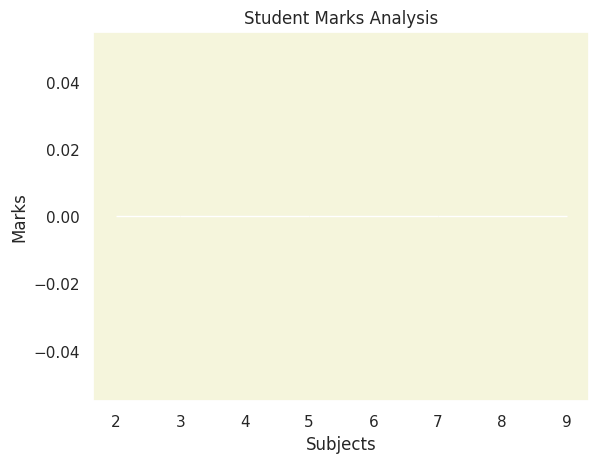

In [ ]:
import matplotlib.pyplot as plt

#subjects = ['Maths', 'Science', 'English', 'Social', 'Computer']
marks = [85, 90, 92, 95, 97]
frequency = [2,3,5,7,9]
plt.hist(marks,frequency)

plt.xlabel("Subjects")
plt.ylabel("Marks")
plt.title("Student Marks Analysis")

plt.show()


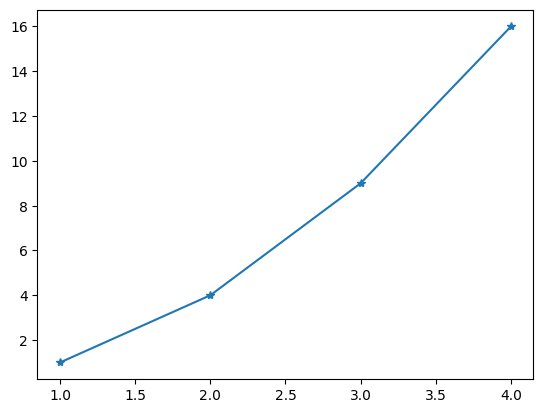

In [ ]:
import matplotlib.pyplot as plt
x=[1, 2, 3, 4]
y=[1, 4, 9, 16]
plt.plot(x,y,marker='*')
plt.show()


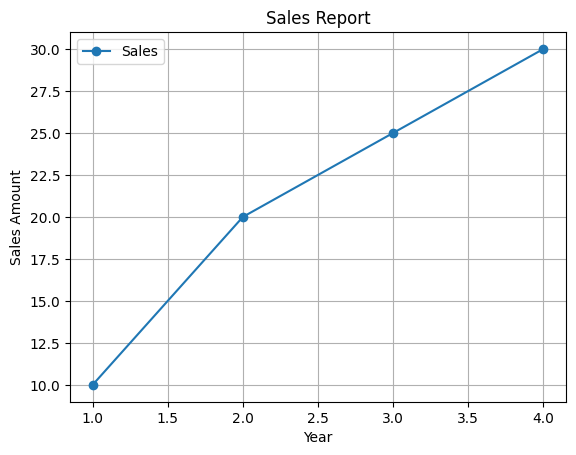

In [ ]:
import matplotlib.pyplot as plt

x = [1, 2, 3, 4]
y = [10, 20, 25, 30]

plt.plot(x, y, label="Sales",marker='o')
plt.title("Sales Report")
plt.xlabel("Year")
plt.ylabel("Sales Amount")
plt.legend()
plt.grid(True)
plt.show()



In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
%matplotlib inline

pd.set_option('display.precision', 2)
sns.set(rc={"axes.facecolor":"Beige" , "axes.grid" : False})
#plt.style.use('fivethirtyeight')
import warnings
warnings.filterwarnings("ignore")
df = pd.read_csv("heart_disease_uci.csv")
print(f"Records: {df.shape[0]}")
df = df.dropna()
df.head()

Records: 920


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


<Axes: xlabel='year', ylabel='passengers'>

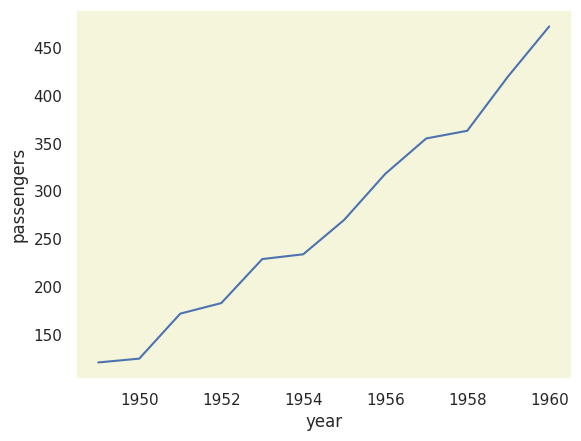

In [ ]:
flights = sns.load_dataset("flights")
flights.head()
may_flights = flights.query("month == 'May'")
sns.lineplot(data=may_flights, x="year", y="passengers")


In [ ]:
print(f"Records: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Records: 299
Columns: 16


In [ ]:
import pandas as pd
df = pd.read_csv("heart_disease_uci.csv")
df_na = df.isna()
df_na.tail(19)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
901,False,False,False,False,False,True,True,False,False,True,True,True,True,True,True,False
902,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
903,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
904,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False
905,False,False,False,False,False,True,False,False,False,True,True,True,True,True,True,False
906,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True,False
907,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True,False
908,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False
909,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False
910,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False


In [ ]:
print(df['cp'].value_counts().nlargest(2).index)

Index(['asymptomatic', 'non-anginal'], dtype='object', name='cp')


In [ ]:
print(df['restecg'].value_counts().nlargest(2).index)

Index(['normal', 'lv hypertrophy'], dtype='object', name='restecg')


Index(['asymptomatic', 'non-anginal', 'atypical angina', 'typical angina'], dtype='object', name='cp')


Index(['asymptomatic', 'non-anginal', 'atypical angina', 'typical angina'], dtype='object', name='cp')

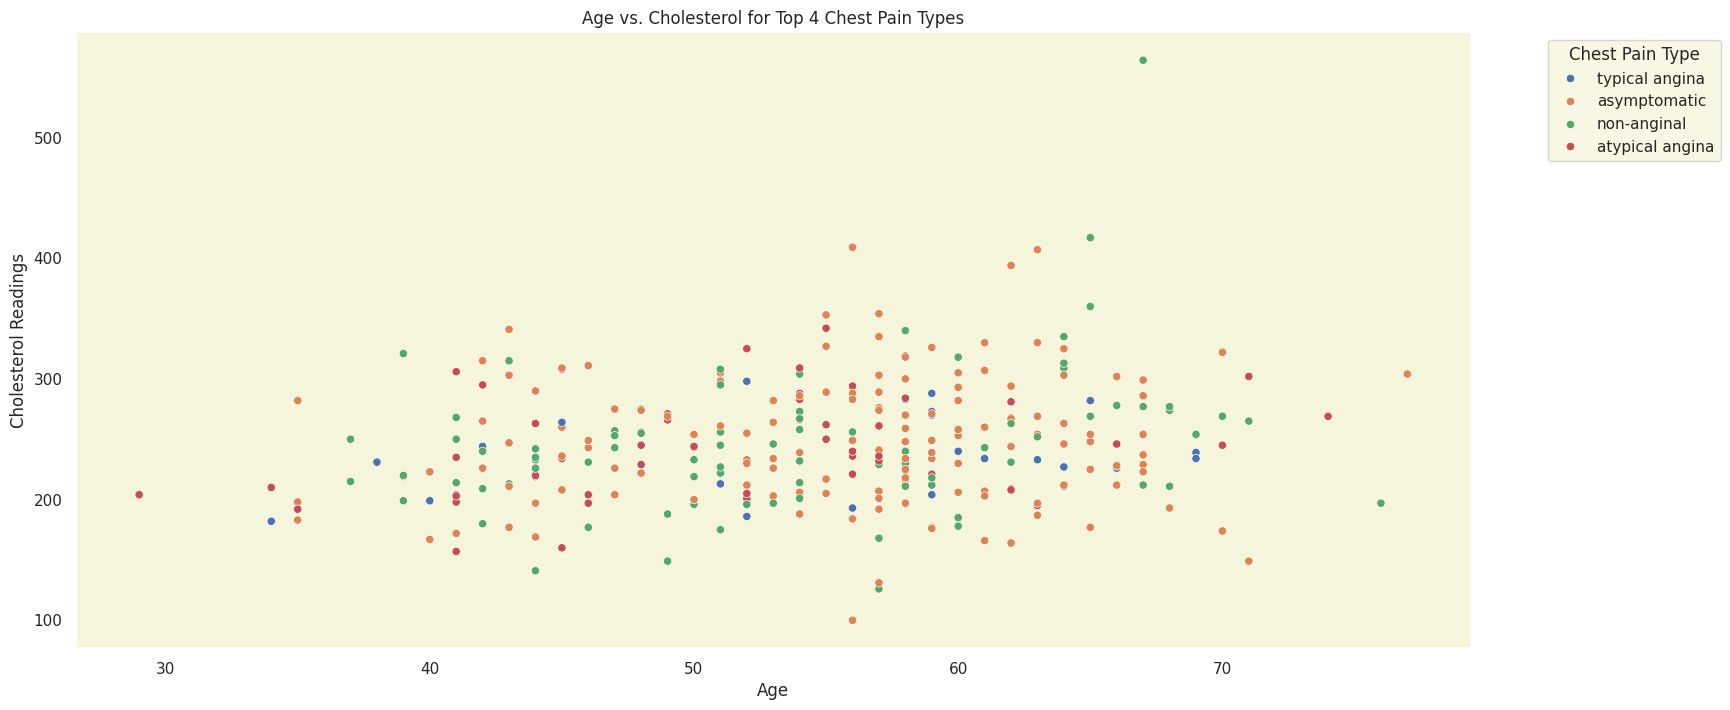

In [ ]:
print(df['cp'].value_counts().nlargest(4).index)
top_leagues = df['cp'].value_counts().nlargest(4).index
display(top_leagues)

plt.figure(figsize=(18, 8))
sns.scatterplot(x='age', y='chol', data=df[df['cp'].isin(top_leagues)], hue='cp')
plt.title('Age vs. Cholesterol for Top 4 Chest Pain Types')
plt.xlabel('Age')
plt.ylabel('Cholesterol Readings')
plt.legend(title='Chest Pain Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [ ]:
import plotly.express as px
print(df['sex'].value_counts())

fig = px.scatter(df, y='chol', x='age', color='sex')

fig.update_layout(width=800, height=400)

fig.update_layout(title_text='Scatter Plot of Cholesterol vs. Age (colored by Sex)')

fig.show()

sex
Male      203
Female     96
Name: count, dtype: int64


In [ ]:
import plotly.express as px


fig = px.scatter(df, y='chol', x='age', color='cp', size = 'oldpeak', size_max = 20, hover_name = 'exang')

fig.update_layout(width=1800, height=600)

fig.update_layout(title_text='Scatter Plot of Cholesterol vs. Age (colored by cp)')

fig.show()

In [ ]:
fig=px.bar(df,x='age',y='thalch',hover_data='trestbps',barmode='stack',color='sex',height=200)
fig.show()

In [ ]:
def generate_rating_df(df):
    rating_df = df.groupby(['cp', 'slope']).agg({'id': 'count'}).reset_index()
    rating_df = rating_df[rating_df['id'] != 0]
    rating_df.columns = ['cp', 'slope', 'counts']
    rating_df = rating_df.sort_values('slope')
    return rating_df

rating_df = generate_rating_df(df)
fig = px.bar(rating_df, x='cp', y='counts', color='slope')

fig.update_traces(textposition='auto',
                  textfont_size=16)

fig.update_layout(barmode='stack')

fig.show()



In [ ]:
def generate_rating_df(df):
    rating_df = df.groupby(['cp', 'slope']).agg({'id': 'count'}).reset_index()
    rating_df = rating_df[rating_df['id'] != 0]
    rating_df.columns = ['cp', 'slope', 'counts']
    rating_df = rating_df.sort_values('slope')
    return rating_df

rating_df = generate_rating_df(df)
fig = px.bar(rating_df, x='cp', y='counts', color='slope')

fig.update_traces(textposition='auto',
                  textfont_size=20)

fig.update_layout(barmode='group')

fig.show()

In [ ]:
import plotly.express as px

def generate_rating_df(df):
    rating_df = df.groupby(['cp', 'slope']).agg({'id': 'count'}).reset_index()
    rating_df = rating_df[rating_df['id'] != 0]
    rating_df.columns = ['cp', 'slope', 'counts']
    rating_df = rating_df.sort_values('slope')
    return rating_df

rating_df = generate_rating_df(df)


fig = px.bar(rating_df, x='cp', y='counts', color='slope', barmode='group',
             text='counts',
             )

fig.update_traces(textposition='auto',
                  textfont_size=20)

fig.show()



In [ ]:
def generate_rating_df(df):
    rating_df = df.groupby(['cp', 'slope']).agg({'id': 'count'}).reset_index()
    rating_df = rating_df[rating_df['id'] != 0]
    rating_df.columns = ['cp', 'slope', 'counts']
    rating_df = rating_df.sort_values('slope')

    # Calculate percentages
    total_counts = rating_df['counts'].sum()
    rating_df['percentage'] = rating_df['counts'] / total_counts * 100

    return rating_df

rating_df = generate_rating_df(df)

fig = px.bar(rating_df, x='cp', y='counts', color='slope', text='percentage')

fig.update_traces(
    texttemplate='%{text:.1f}%',
    textposition='outside',
    textfont_size=16
)

fig.update_layout(
    barmode='group',
    yaxis_title='Count',
    xaxis_title='CP',
    legend_title='Slope'
)

fig.update_layout(
    height=550,
    width=1500,
    title_text="Distribution of Chest Pain Type by Percentage",
    title_font_size=24
)


fig.show()



In [ ]:
fig = px.scatter(data_frame = df,
                 x="age",
                 y="chol",
                 color="cp",
                 size='ca',
                 hover_data=['oldpeak'],
                 marginal_x="histogram",
                 marginal_y="box",)
fig.show()

In [ ]:

fig.update_layout(title_text="<b> Age vs Cholesterol <b>",
                  titlefont={'size': 24, 'family':'Serif'},
                  width=1500,
                  height=750,
                 )

fig.show()

In [ ]:
fig= px.histogram(df, x='age',height=500,width=900,template='simple_white',
                  color='sex', # adding categorical column
                  color_discrete_sequence=['purple','pink'])




fig.update_layout(title={'text':'Histogram of Persons by Age','font':{'size':25}}
                    ,title_font_family="Times New Roman",
    title_font_color="darkgrey",


                 title_x=0.2)

fig.update_layout(
    font_family='classic-roman',
                  font_color= 'grey',
                  yaxis_title={'text': "Number of occurrence", 'font': {'size':18}},
                xaxis_title={'text': " Age", 'font': {'size':18}}
)
fig.show()

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Assuming df is your DataFrame
asymptomatic = df[df['cp'] == 'asymptomatic']
print(asymptomatic.shape[0])
non_anginal = df[df['cp'] == 'non-anginal']
atypical_angina = df[df['cp'] == 'atypical angina']
typical_angina = df[df['cp'] == 'typical angina']

fig = make_subplots(rows=2,
                    cols=2,
                    specs=[[{'type':'domain'}, {'type':'domain'}],
                           [{'type':'domain'}, {'type':'domain'}]],
                    subplot_titles=("Asymptomatic", "Non-Anginal",
                                    "Atypical Angina", "Typical Angina"))

fig.add_trace(go.Pie(labels=asymptomatic["thal"], values=asymptomatic["chol"], name="asymptomatic"), 1, 1)
fig.add_trace(go.Pie(labels=non_anginal["thal"], values=non_anginal["chol"], name="non_anginal"), 1, 2)
fig.add_trace(go.Pie(labels=atypical_angina["thal"], values=atypical_angina["chol"], name="atypical_angina"), 2, 1)
fig.add_trace(go.Pie(labels=typical_angina["thal"], values=typical_angina["chol"], name="typical_angina"), 2, 2)

# Update layout to increase the size of the plot and add main title
fig.update_layout(
    height=1200,
    width=1500,
    title_text="Distribution of Cholesterol Levels by Chest Pain Type",
    title_font_size=24
)

# Update traces
fig.update_traces(textposition='inside', textfont_size=16)
fig.update_annotations(font_size=20)
fig.show()

144


In [ ]:
from plotly.offline import iplot

category = df["cp"].value_counts()

fig = px.bar(category,
             x = category.index,
             y =  (category / sum(category)) *  100,
             color=category.index,
             labels={"y" : "Frequency in (Percentage%)", "category":"Category"},
             title="Frequency of Chest Pain Category in Percentage",
             text = category.apply(lambda x: f'{(x / sum(category)) * 100:.1f}%'),
             template="plotly_dark"
            )

fig.update_layout(showlegend=False)
fig.update_traces(
    textfont= {
        "family": "consolas",
        "size": 20,
    }
)


iplot(fig)